In [1]:
# ========================
# 1. IMPORT LIBRARIES
# ========================
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ========================
# 2. LOAD DATA
# ========================
data=pd.read_csv('googleplaystore.csv')
print("Shape: ",data.shape)

Shape:  (10841, 13)


In [5]:
# ========================
# 3. CLEAN DATA
# ========================

#Xóa missing value
data=data.dropna()
print(data.shape)

#Sort data theo reviews để xóa duplicate lấy theo reviews cao nhất
data=data.sort_values('Reviews',ascending= False)
data=data.drop_duplicates(subset='App',keep='first')
print(data.shape)


(9360, 13)
(8190, 13)


In [10]:
# ========================
# 4. CONVERT DATATYPE
# ========================

#Convert kiểu dữ liệu cần xử lí
data['Reviews'] = data['Reviews'].astype(float)
data['Rating'] = data['Rating'].astype(float)
data['Price']=data['Price'].replace('$','').astype(float)

In [ ]:
# ========================
# 5. ANALYSIS
# ========================

#Lọc free app và paid app
free_app=data[data['Price']==0]
paid_app=data[data['Price']!=0]

#So sánh Rating trung bình
print("All rating: ",data['Rating'].mean())
print("Free app rating: ",free_app['Rating'].mean())
print("Paid app rating: ",paid_app['Rating'].mean())

#So sánh các category dự trên số lượng rating và rating trung bình 

category_sumary=data.groupby('Category')['Rating'].agg(['mean','count'])
print(category_sumary.sort_values(by=['mean','count'],ascending=False))




All rating:  4.173162393162393
Free app rating:  4.166288877174486
Paid app rating:  4.259800664451826
                         mean  count
Category                            
EVENTS               4.435556     45
ART_AND_DESIGN       4.379310     58
EDUCATION            4.353333    105
BOOKS_AND_REFERENCE  4.344970    169
PERSONALIZATION      4.331419    296
PARENTING            4.300000     50
BEAUTY               4.278571     42
SOCIAL               4.247291    203
GAME                 4.243352    895
WEATHER              4.243056     72
HEALTH_AND_FITNESS   4.243033    244
SHOPPING             4.230556    180
SPORTS               4.216154    260
AUTO_AND_VEHICLES    4.190411     73
FAMILY               4.184332   1653
PRODUCTIVITY         4.183389    301
COMICS               4.181481     54
LIBRARIES_AND_DEMO   4.179365     63
FOOD_AND_DRINK       4.171277     94
MEDICAL              4.166552    290
PHOTOGRAPHY          4.157414    263
HOUSE_AND_HOME       4.140984     61
ENTERTAIN

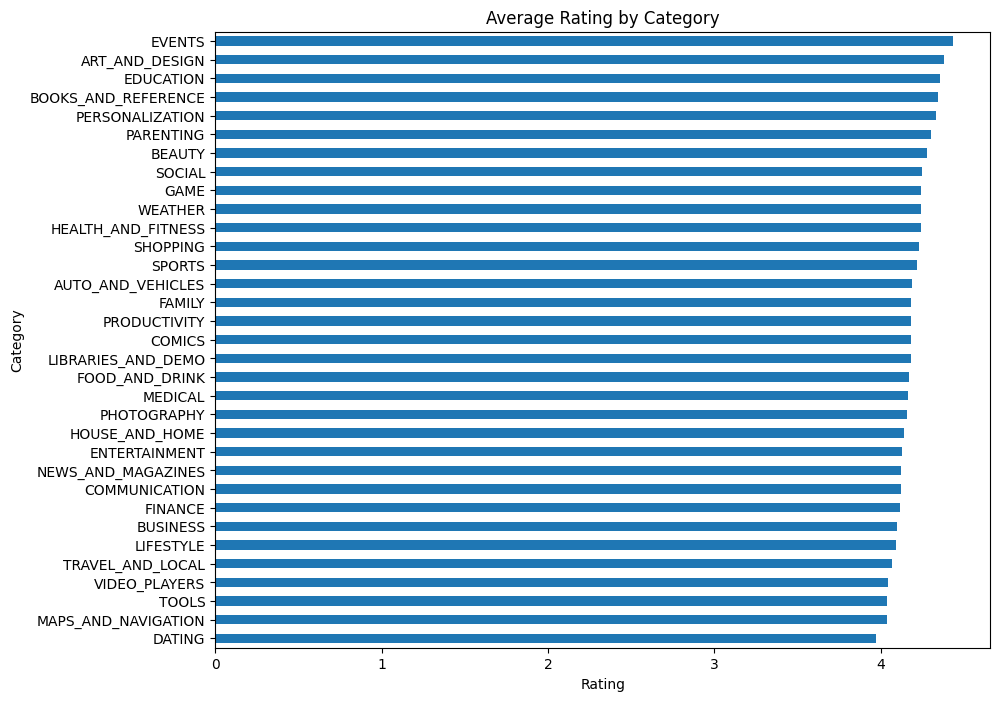

In [21]:
# ========================
# 6. VISUALIZATION
# ========================

category_sumary['mean'].sort_values().plot(kind='barh', figsize=(10,8))

plt.title("Average Rating by Category")
plt.xlabel("Rating")
plt.ylabel("Category")

plt.show()

In [ ]:
# ========================
# 8. INSIGHT
# ========================

print("""
- Rating trung bình khá cao (~4.17)
- App paid có rating cao hơn free nhưng không đáng kể -> Người dùng có xu hướng đánh giá cao hơn với những sản phẩm có đầu tư và chất lượng tốt tuy nhiên free app vẫn có chất lượng không kém cạnh
- Một số category có rating cao nhưng số lượng ít → Mức độ tin cậy chưa cao
""")

In [ ]:
print("""
Mục tiêu của phân tích là tìm hiểu đặc điểm các ứng dụng trên Google play và xác định ứng dụng có tiềm năng phát triển.
      
Phân tích cho thấy phần lớn ứng dụng có rating khá cao (~4.17), phản ánh mức độ hài lòng chung của người dùng.
Ứng dụng trả phí có rating cao hơn ứng dụng miễn phí, tuy nhiên số lượng ứng dụng miễn phí vẫn chiếm đa số trên thị trường.
Ngoài ra, có sự khác biệt rõ rệt giữa các category, trong đó một số category có rating cao nhưng số lượng ứng dụng thấp.
      
Mặc dù một số category có rating cao, nhưng số lượng dữ liệu ít khiến kết quả có thể không đáng tin cậy. Ngược lại, các category có nhiều ứng dụng và rating ổn định sẽ phản ánh chính xác hơn xu hướng người dùng.
Bên cạnh đó, việc ứng dụng trả phí có rating cao hơn cho thấy chất lượng sản phẩm có thể ảnh hưởng đến đánh giá của người dùng, tuy nhiên không phải là yếu tố quyết định duy nhất.
      
Từ các phân tích trên, có thể thấy rằng để phát triển ứng dụng hiệu quả, nên tập trung vào các category có nhiều ứng dụng và rating ổn định, đồng thời đảm bảo chất lượng sản phẩm để cải thiện trải nghiệm người dùng.
""")